In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("banana_quality_dataset.csv")
df

,sample_id,variety,region,quality_score,quality_category,ripeness_index,ripeness_category,sugar_content_brix,firmness_kgf,length_cm,weight_g,harvest_date,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
0,1,Manzano,Colombia,1.88,Processing,2.11,Turning,16.83,3.53,21.44,146.92,2023-10-16,13.7,58.2,2440.5,183.6
1,2,Plantain,Guatemala,2.42,Processing,4.25,Ripe,16.73,4.09,26.11,160.48,2023-10-14,5.1,280.2,2374.6,109.8
2,3,Burro,Ecuador,3.57,Premium,6.24,Overripe,21.34,1.63,25.20,225.27,2023-09-08,17.7,1246.9,1191.5,147.7
3,4,Manzano,Ecuador,2.21,Processing,5.39,Ripe,16.75,3.31,13.08,137.80,2023-10-07,13.0,1150.2,2845.1,92.8
4,5,Red Dacca,Ecuador,2.35,Processing,5.84,Ripe,16.90,3.07,12.98,227.84,2023-10-02,4.8,526.0,2136.9,129.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Burro,Ecuador,3.50,Good,4.94,Ripe,21.06,2.49,27.95,196.35,2023-10-04,12.4,409.7,2029.9,173.0
996,997,Cavendish,Philippines,2.38,Processing,6.74,Overripe,16.10,2.00,12.39,165.55,2023-09-23,14.0,314.3,1330.7,180.5
997,998,Plantain,Ecuador,1.68,Processing,1.41,Green,17.17,2.28,16.56,210.08,2023-10-19,18.4,683.0,2955.4,189.9
998,999,Fehi,Guatemala,2.02,Processing,1.34,Green,17.03,2.88,26.31,162.50,2023-09-22,8.2,1362.7,1215.8,85.5


In [4]:
df.isnull().sum()

sample_id             0
variety               0
region                0
quality_score         0
quality_category      0
ripeness_index        0
ripeness_category     0
sugar_content_brix    0
firmness_kgf          0
length_cm             0
weight_g              0
harvest_date          0
tree_age_years        0
altitude_m            0
rainfall_mm           0
soil_nitrogen_ppm     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

ValueError: num must be an integer with 1 <= num <= 9, not 10

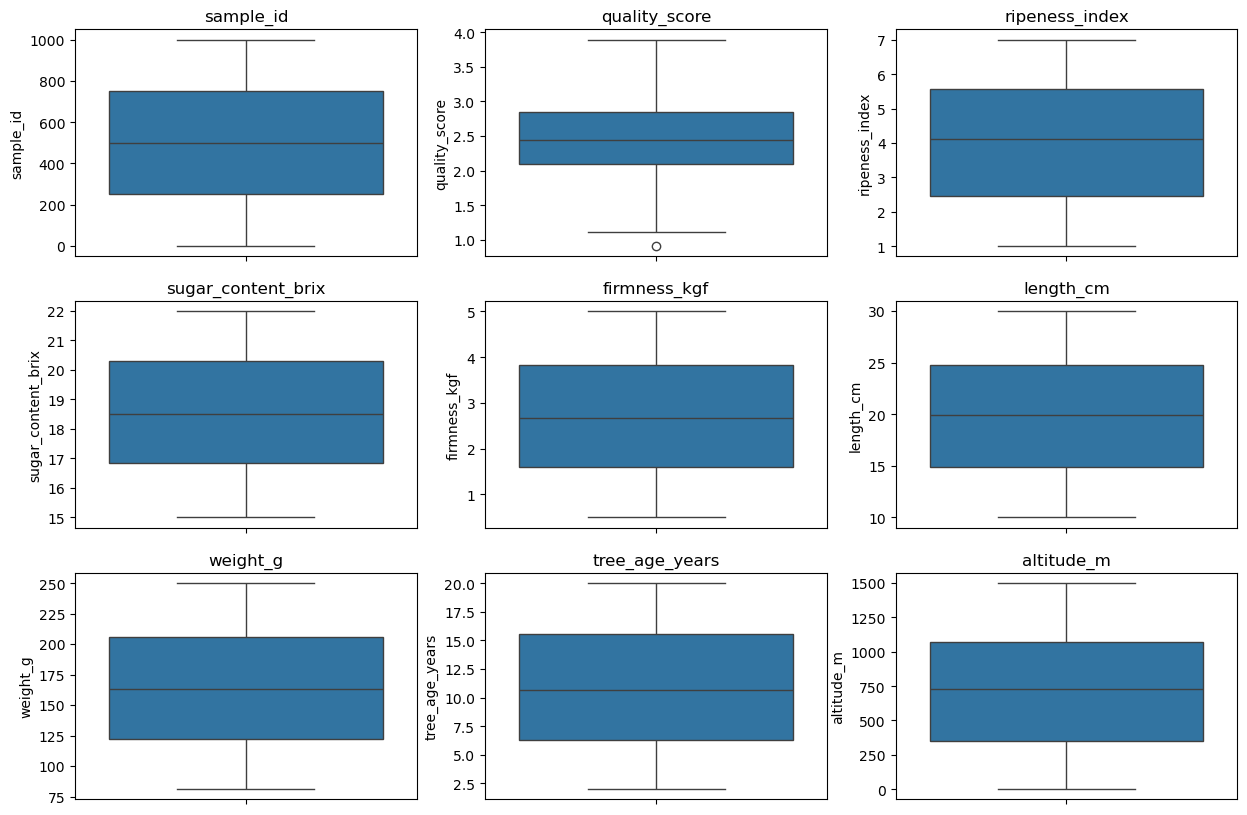

In [6]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [7]:
y=df["quality_category"]

In [8]:
x=df.drop(["quality_category"],axis=1)

In [9]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           1000 non-null   int64  
 1   variety             1000 non-null   object 
 2   region              1000 non-null   object 
 3   quality_score       1000 non-null   float64
 4   ripeness_index      1000 non-null   float64
 5   ripeness_category   1000 non-null   object 
 6   sugar_content_brix  1000 non-null   float64
 7   firmness_kgf        1000 non-null   float64
 8   length_cm           1000 non-null   float64
 9   weight_g            1000 non-null   float64
 10  harvest_date        1000 non-null   object 
 11  tree_age_years      1000 non-null   float64
 12  altitude_m          1000 non-null   float64
 13  rainfall_mm         1000 non-null   float64
 14  soil_nitrogen_ppm   1000 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory usage: 117.3+

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

ct = ColumnTransformer( transformers=[("oe",OrdinalEncoder(),[1,2,5,10])])

x_transformed = ct.fit_transform(x)

x_transformed = pd.DataFrame(x_transformed)

print(x_transformed)

       0    1    2     3
0    5.0  1.0  3.0  45.0
1    6.0  4.0  2.0  43.0
2    1.0  3.0  1.0   7.0
3    5.0  3.0  2.0  36.0
4    7.0  3.0  2.0  31.0
..   ...  ...  ...   ...
995  1.0  3.0  2.0  33.0
996  2.0  7.0  1.0  22.0
997  6.0  3.0  0.0  48.0
998  3.0  4.0  0.0  21.0
999  7.0  3.0  3.0  28.0

[1000 rows x 4 columns]


In [11]:
from sklearn.preprocessing import StandardScaler
ct=ColumnTransformer(transformers=[("sc",StandardScaler(),[0,3,4,6,7,8,9,11,12,13,14])])

In [12]:
x_transformed=ct.fit_transform(x)

In [13]:
x_transformed = pd.DataFrame(x_transformed)

print(x_transformed)

           0         1         2         3         4         5         6   \
0   -1.730320 -1.082350 -1.102626 -0.829400  0.638798  0.271721 -0.362627   
1   -1.726856 -0.083531  0.118602 -0.878570  1.073376  1.086240 -0.086672   
2   -1.723391  2.043584  1.254230  1.388129 -0.835662  0.927522  1.231846   
3   -1.719927 -0.471961  0.769163 -0.868736  0.468071 -1.186389 -0.548225   
4   -1.716463 -0.213007  1.025963 -0.794982  0.281824 -1.203830  1.284148   
..        ...       ...       ...       ...       ...       ...       ...   
995  1.716463  1.914108  0.512362  1.250456 -0.168275  1.407163  0.643306   
996  1.719927 -0.157518  1.539564 -1.188335 -0.548530 -1.306735  0.016506   
997  1.723391 -1.452283 -1.502094 -0.662225 -0.331241 -0.579424  0.922720   
998  1.726856 -0.823397 -1.542040 -0.731062  0.134378  1.121123 -0.045564   
999  1.730320  0.415879 -0.771639  1.270123 -1.146075  0.360673 -1.207789   

           7         8         9         10  
0    0.541038 -1.557632  0.82

In [14]:
from sklearn.feature_selection import mutual_info_classif
mf=mutual_info_classif(x_transformed,y)
mf=pd.Series(mf)
mf.index=x_transformed.columns
mf.sort_values(ascending=False)

1     0.913807
2     0.239676
3     0.165680
5     0.058129
9     0.025614
4     0.004275
0     0.002710
6     0.000000
7     0.000000
8     0.000000
10    0.000000
dtype: float64

In [15]:
x.drop(["weight_g","firmness_kgf","tree_age_years","soil_nitrogen_ppm",],axis=1,inplace=True)

In [16]:
x.drop(["altitude_m"],axis=1,inplace=True)

In [1]:
x.shape

NameError: name 'x' is not defined

In [18]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [19]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           1000 non-null   int64  
 1   variety             1000 non-null   object 
 2   region              1000 non-null   object 
 3   quality_score       1000 non-null   float64
 4   ripeness_index      1000 non-null   float64
 5   ripeness_category   1000 non-null   object 
 6   sugar_content_brix  1000 non-null   float64
 7   length_cm           1000 non-null   float64
 8   harvest_date        1000 non-null   object 
 9   rainfall_mm         1000 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 78.3+ KB


In [20]:
ct=ColumnTransformer(transformers=[("oe",OrdinalEncoder(),[1,2,5,8]),
                                   ("sc",StandardScaler(),[0,3,4,6,7,9])])

In [21]:
x_train_transform=ct.fit_transform(x_train)
x_tarin_transorm=pd.DataFrame(x_train_transform)

In [22]:
x_test_transform=ct.transform(x_test)
x_test_transform=pd.DataFrame(x_test_transform)

In [23]:
from sklearn.naive_bayes import GaussianNB
gn=GaussianNB()
gn.fit(x_train_transform,y_train)
y_pred=gn.predict(x_test_transform)

In [24]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,y_pred,average="micro")
f1

0.965

In [25]:
y_pred=gn.predict(x_train_transform)
f1=f1_score(y_train,y_pred,average="micro")
f1

0.95375